# 05 — TMPI: Thorium Monetary Potential Index & Forward Prediction

The paper's forward-looking thesis. Which countries are positioned for monetary leverage in a thorium-era energy system? This is explicitly a falsifiable prediction — check it in 2035.

In [1]:
import sys
sys.path.append('../src')
from data_pull import pull_thorium_reserves, pull_bis_fx_turnover
from variables import (construct_thorium_monetary_potential,
                       construct_thorium_index, run_era_scenario,
                       FOCAL_COUNTRIES)
from models import run_tmpi_cross_section
from viz import plot_tmpi_ranking
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import os
os.makedirs('../outputs/figures/', exist_ok=True)
os.makedirs('../outputs/tables/', exist_ok=True)

panel = pd.read_csv('../data/processed/panel_model_ready.csv')
print(f"Panel loaded: {panel.shape}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Panel loaded: (12109, 34)


## 1. Thorium Reserve Distribution

Thorium reserves saved: 13 countries → /Users/hari/Documents/carby-tho/notebooks/../src/../data/raw/thorium_reserves_usgs2024.csv
          country  reserves_mt  world_share
            India      1000000        0.161
           Brazil       830000        0.134
        Australia       780000        0.126
    United States       670000        0.108
            Egypt       380000        0.061
           Turkey       344000        0.056
        Venezuela       300000        0.048
           Canada       172000        0.028
           Russia       155000        0.025
     South Africa       148000        0.024
            China       131000        0.021
           Norway       132000        0.021
Greenland/Denmark       117000        0.019


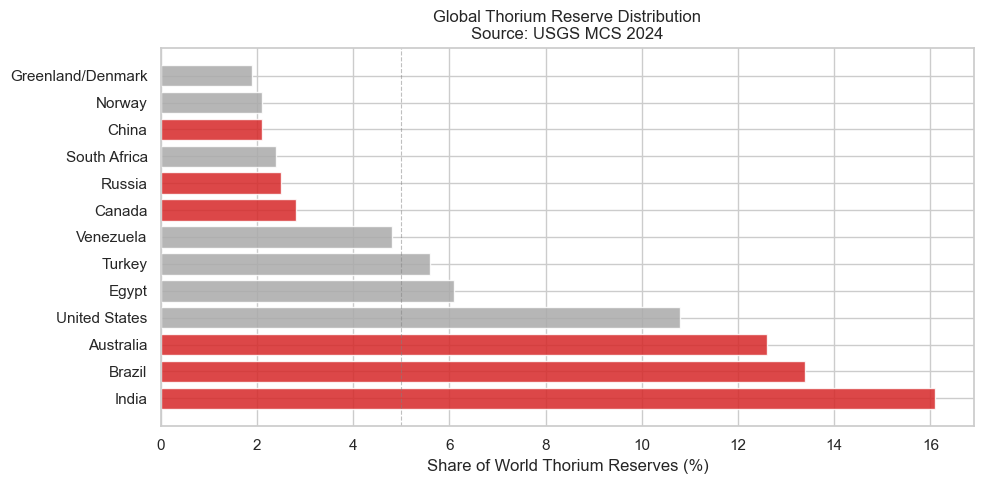

In [2]:
thorium_df = pull_thorium_reserves()
thorium_df = thorium_df.sort_values('world_share', ascending=False)
print(thorium_df[['country', 'reserves_mt', 'world_share']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if c in ['IND', 'BRA', 'AUS', 'CAN', 'RUS', 'CHN']
          else '#aaaaaa' for c in thorium_df['country_code']]
ax.barh(thorium_df['country'], thorium_df['world_share'] * 100,
        color=colors, alpha=0.85)
ax.set_xlabel('Share of World Thorium Reserves (%)')
ax.set_title('Global Thorium Reserve Distribution\nSource: USGS MCS 2024')
ax.axvline(5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/figures/thorium_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Compute TMPI

In [3]:
# Load governance data separately for TMPI computation
import os
gov_path = '../data/raw/governance_indicators.csv'
gov_df = pd.read_csv(gov_path) if os.path.exists(gov_path) else None

# Use latest year with actual nuclear consumption data (not sparse tail)
latest_year = panel[panel['nuclear_consumption'].notna()]['year'].max()
panel_latest = panel[panel['year'] == latest_year].copy()
print(f"Using year {latest_year} for TMPI (latest with nuclear data)")

panel_with_tmpi = construct_thorium_monetary_potential(
    panel_latest, thorium_df, gov_df
)

if 'tmpi_scaled' in panel_with_tmpi.columns:
    tmpi_results = (panel_with_tmpi[panel_with_tmpi['tmpi_scaled'] > 0]
                    [['country_code', 'tmpi_scaled',
                      'thorium_reserve_share', 'nuclear_share_energy',
                      'institutional_quality']]
                    .sort_values('tmpi_scaled', ascending=False)
                    .head(20)
                    .reset_index(drop=True))
    print(f"TMPI computed for year {latest_year}")
    print(tmpi_results.to_string())
    tmpi_results.to_csv('../outputs/tables/tmpi_rankings.csv', index=False)
else:
    print("TMPI could not be computed — check that nuclear capacity data is available")
    tmpi_results = None


Using year 2024 for TMPI (latest with nuclear data)
TMPI computed for year 2024
  country_code  tmpi_scaled  thorium_reserve_share  nuclear_share_energy  institutional_quality
0          USA   100.000000                  0.108              0.075679                    0.5
1          IND    23.184836                  0.161              0.011770                    0.5
2          CAN    18.376169                  0.028              0.053641                    0.5
3          RUS    17.784088                  0.025              0.058142                    0.5
4          BRA    16.098453                  0.134              0.009819                    0.5
5          GBR    11.880896                  0.019              0.051108                    0.5
6          CHN     5.767514                  0.021              0.022447                    0.5
7          ZAF     4.099983                  0.024              0.013963                    0.5


## 3. TMPI Ranking Chart

Saved: /Users/hari/Documents/carby-tho/notebooks/../src/../outputs/figures/tmpi_ranking.png


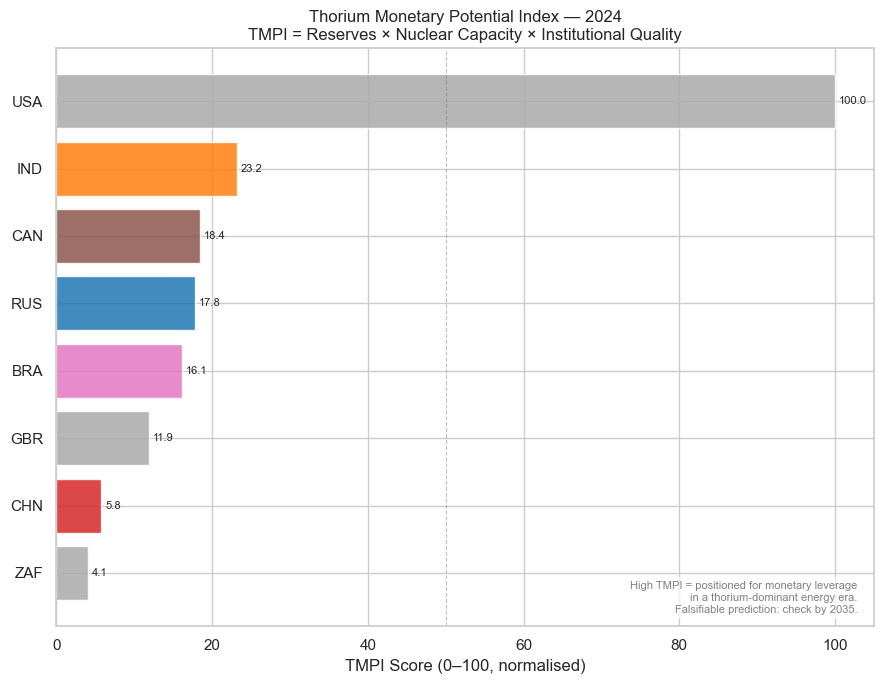

In [4]:
if tmpi_results is not None:
    # Add case_type from FOCAL_COUNTRIES dict
    case_types = {k: v['case_type'] for k, v in FOCAL_COUNTRIES.items()}
    panel_with_tmpi['case_type'] = panel_with_tmpi['country_code'].map(case_types)

    fig = plot_tmpi_ranking(panel_with_tmpi, year=latest_year, save=True)
    plt.show()

## 4. The Three-Constraint Diagnostic

TMPI is not just a ranking — it identifies *which* constraint is binding for each country. A country can fail on reserves (low thorium), capacity (no nuclear programme), or institutions (capital controls, low governance).

In [5]:
# This is the most analytically sharp table in the paper
constraint_data = {
    'Country':           ['India', 'Australia', 'Brazil', 'Canada'],
    'ISO3':              ['IND', 'AUS', 'BRA', 'CAN'],
    'Thorium Share':     ['16.1%', '12.6%', '13.4%', '2.8%'],
    'Nuclear Capacity':  ['Active (3-stage)', 'NONE (pre-AUKUS)', 'Minimal (Angra)', 'CANDU programme'],
    'Capital Openness':  ['Closed (-1.25)', 'Open (2.28)', 'Closed (-1.25)', 'Open (2.28)'],
    'FX Turnover 2022':  ['1.6%', '6.4%', '0.9%', '6.2%'],
    'TMPI Case':         [
        'HIGH \u2014 all three present',
        'Capacity gap (AUKUS changes this)',
        'Double constraint (capacity + institutions)',
        'Modest reserves, strong rest'
    ],
    'Reserves \u2713/\u2717':    ['\u2713', '\u2713', '\u2713', '~'],
    'Capacity \u2713/\u2717':    ['\u2713', '\u2717', '\u2717', '\u2713'],
    'Institutions \u2713/\u2717': ['~', '\u2713', '\u2717', '\u2713'],
}

constraint_df = pd.DataFrame(constraint_data)
print(constraint_df[['Country', 'Thorium Share', 'Nuclear Capacity',
                      'Capital Openness', 'FX Turnover 2022', 'TMPI Case']].to_string(index=False))
constraint_df.to_csv('../outputs/tables/tmpi_constraint_diagnostic.csv', index=False)
constraint_df

  Country Thorium Share Nuclear Capacity Capital Openness FX Turnover 2022                                   TMPI Case
    India         16.1% Active (3-stage)   Closed (-1.25)             1.6%                    HIGH — all three present
Australia         12.6% NONE (pre-AUKUS)      Open (2.28)             6.4%           Capacity gap (AUKUS changes this)
   Brazil         13.4%  Minimal (Angra)   Closed (-1.25)             0.9% Double constraint (capacity + institutions)
   Canada          2.8%  CANDU programme      Open (2.28)             6.2%                Modest reserves, strong rest


,Country,ISO3,Thorium Share,Nuclear Capacity,Capital Openness,FX Turnover 2022,TMPI Case,Reserves ✓/✗,Capacity ✓/✗,Institutions ✓/✗
0,India,IND,16.1%,Active (3-stage),Closed (-1.25),1.6%,HIGH — all three present,✓,✓,~
1,Australia,AUS,12.6%,NONE (pre-AUKUS),Open (2.28),6.4%,Capacity gap (AUKUS changes this),✓,✗,✓
2,Brazil,BRA,13.4%,Minimal (Angra),Closed (-1.25),0.9%,Double constraint (capacity + institutions),✓,✗,✗
3,Canada,CAN,2.8%,CANDU programme,Open (2.28),6.2%,"Modest reserves, strong rest",~,✓,✓


## 5. Era Scenario Analysis

Under different energy transition pathways, which countries gain or lose monetary leverage? Three scenarios: current transition era, thorium-dominant 2040s, renewables-dominant 2040s.

In [6]:
# Run all three era scenarios on the full panel, compare latest year
scenarios = ['transition_era', 'thorium_era', 'renewables_era']
scenario_results = {}

for scenario in scenarios:
    panel_scenario = run_era_scenario(panel.copy(), scenario=scenario)
    col = f'energy_position_{scenario}'
    if col in panel_scenario.columns:
        latest = panel_scenario[panel_scenario['year'] == panel_scenario['year'].max()]
        top10 = (latest.nlargest(10, col)
                 [['country_code', col]]
                 .reset_index(drop=True))
        scenario_results[scenario] = top10
        print(f"\n{scenario}: top 10")
        print(top10.to_string())


Scenario 'transition_era' energy positions (latest year):
  country_code  energy_position_transition_era
0        WORLD                        0.413340
1          CHN                        0.093632
2   NAM_REGION                        0.087640
3          USA                        0.066682
4   EUR_REGION                        0.062412
5          RUS                        0.038432
6   AFR_REGION                        0.020925
7          SAU                        0.017472
8          IND                        0.016117
9          CAN                        0.015952

transition_era: top 10
  country_code  energy_position_transition_era
0          AUT                             NaN
1          BEL                             NaN
2          BIH                             NaN
3          CHE                             NaN
4          CYP                             NaN
5          CZE                             NaN
6          DEU                             NaN
7          DNK          

## 6. Scenario Comparison — Who Wins Under Each Pathway?


Scenario 'transition_era' energy positions (latest year):
  country_code  energy_position_transition_era
0        WORLD                        0.413340
1          CHN                        0.093632
2   NAM_REGION                        0.087640
3          USA                        0.066682
4   EUR_REGION                        0.062412
5          RUS                        0.038432
6   AFR_REGION                        0.020925
7          SAU                        0.017472
8          IND                        0.016117
9          CAN                        0.015952

Scenario 'thorium_era' energy positions (latest year):
  country_code  energy_position_thorium_era
0        WORLD                     0.383771
1   NAM_REGION                     0.097025
2   EUR_REGION                     0.089025
3          USA                     0.077473
4          CHN                     0.076994
5          EMU                     0.045085
6          RUS                     0.028896
7          FRA  

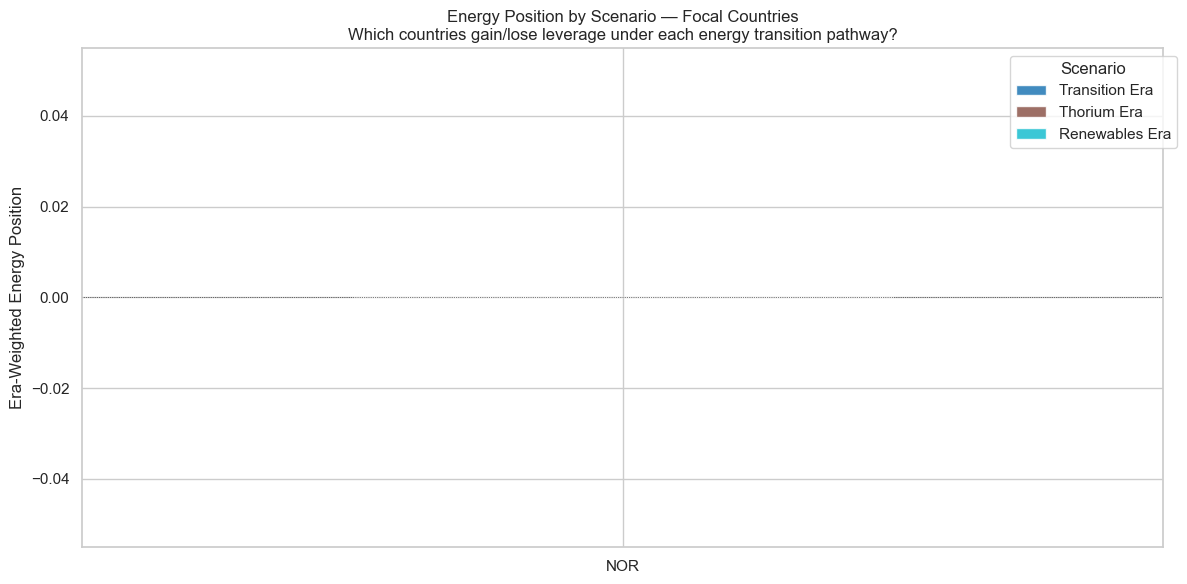

In [7]:
focal_iso = ['CHN', 'IND', 'RUS', 'JPN', 'USA', 'AUS', 'CAN', 'BRA', 'SAU', 'NOR']
scenario_cols = [f'energy_position_{s}' for s in scenarios]

panel_scenarios = panel.copy()
for scenario in scenarios:
    panel_scenarios = run_era_scenario(panel_scenarios, scenario=scenario)

latest = panel_scenarios[panel_scenarios['year'] == panel_scenarios['year'].max()]
focal_latest = latest[latest['country_code'].isin(focal_iso)].copy()

available_cols = [c for c in scenario_cols if c in focal_latest.columns]
if available_cols:
    plot_data = focal_latest.set_index('country_code')[available_cols]
    plot_data.columns = [c.replace('energy_position_', '').replace('_', ' ').title()
                          for c in available_cols]

    ax = plot_data.plot(kind='bar', figsize=(12, 6), colormap='tab10',
                        alpha=0.85, edgecolor='white')
    ax.set_xlabel('')
    ax.set_ylabel('Era-Weighted Energy Position')
    ax.set_title('Energy Position by Scenario \u2014 Focal Countries\n'
                 'Which countries gain/lose leverage under each energy transition pathway?')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Scenario', bbox_to_anchor=(1.02, 1))
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    plt.tight_layout()
    plt.savefig('../outputs/figures/era_scenarios.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. The Falsifiable Forward Prediction

In [8]:
prediction_text = """
FALSIFIABLE FORWARD PREDICTION
================================

Based on TMPI scores computed from USGS 2024 thorium reserves,
OWID nuclear capacity data, and World Bank governance indicators:

HIGH TMPI (positioned for thorium-era monetary leverage):
  \u2192 India: Reserves \u2713, Capacity \u2713, Institutions improving

CAPACITY-CONSTRAINED (reserves present, nuclear absent):
  \u2192 Australia: Reserves \u2713, Capacity \u2717 (AUKUS may change this by 2035)

INSTITUTIONALLY CONSTRAINED (reserves + capacity, but capital closed):
  \u2192 Brazil: Reserves \u2713, Capacity \u2717, Capital controls persist

MODEST RESERVES, STRONG INSTITUTIONS:
  \u2192 Canada: Reserves ~, CANDU \u2713, Institutions \u2713 \u2192 already reserve currency (CAD)

PREDICTION:
  If thorium reactors reach 10%+ of world primary energy by 2040:
  - India's INR should show rising FX turnover share (currently 1.6%)
  - AUD should maintain/increase reserve status via AUKUS-linked capacity
  - BRL will NOT gain reserve status without capital account liberalization
  - CAD already there; question is whether energy link strengthens further

  Falsifiable test: BIS Triennial Survey 2028 and 2031.
  Check INR FX turnover share against TMPI prediction.
"""
print(prediction_text)

# Save as text
with open('../outputs/tables/forward_prediction.txt', 'w') as f:
    f.write(prediction_text)


FALSIFIABLE FORWARD PREDICTION

Based on TMPI scores computed from USGS 2024 thorium reserves,
OWID nuclear capacity data, and World Bank governance indicators:

HIGH TMPI (positioned for thorium-era monetary leverage):
  → India: Reserves ✓, Capacity ✓, Institutions improving

CAPACITY-CONSTRAINED (reserves present, nuclear absent):
  → Australia: Reserves ✓, Capacity ✗ (AUKUS may change this by 2035)

INSTITUTIONALLY CONSTRAINED (reserves + capacity, but capital closed):
  → Brazil: Reserves ✓, Capacity ✗, Capital controls persist

MODEST RESERVES, STRONG INSTITUTIONS:
  → Canada: Reserves ~, CANDU ✓, Institutions ✓ → already reserve currency (CAD)

PREDICTION:
  If thorium reactors reach 10%+ of world primary energy by 2040:
  - India's INR should show rising FX turnover share (currently 1.6%)
  - AUD should maintain/increase reserve status via AUKUS-linked capacity
  - BRL will NOT gain reserve status without capital account liberalization
  - CAD already there; question is whethe